In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_curve, auc
)


In [18]:
df = pd.read_csv(
    "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data",
    header=None
)


df.columns = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race",
    "sex", "capital_gain", "capital_loss", "hours_per_week",
    "native_country", "income"
]

print("\nFirst 10 rows:\n", df.head(10))
print("\nShape:", df.shape)
print("\nColumns:", df.columns.tolist())


First 10 rows:
    age          workclass  fnlwgt   education  education_num  \
0   39          State-gov   77516   Bachelors             13   
1   50   Self-emp-not-inc   83311   Bachelors             13   
2   38            Private  215646     HS-grad              9   
3   53            Private  234721        11th              7   
4   28            Private  338409   Bachelors             13   
5   37            Private  284582     Masters             14   
6   49            Private  160187         9th              5   
7   52   Self-emp-not-inc  209642     HS-grad              9   
8   31            Private   45781     Masters             14   
9   42            Private  159449   Bachelors             13   

           marital_status          occupation    relationship    race  \
0           Never-married        Adm-clerical   Not-in-family   White   
1      Married-civ-spouse     Exec-managerial         Husband   White   
2                Divorced   Handlers-cleaners   Not-in-fami

In [19]:
df.replace(' ?', np.nan, inplace=True)
df.dropna(inplace=True)

In [20]:
df['income'] = df['income'].str.strip()
df['income'] = df['income'].map({'<=50K': 0, '>50K': 1})

In [21]:
df = pd.get_dummies(df, drop_first=True)

In [22]:
X = df.drop('income', axis=1)
y = df['income']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


In [23]:
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

print("\nTree Depth:", model.get_depth())
print("Number of Leaves:", model.get_n_leaves())


Tree Depth: 49
Number of Leaves: 3123


In [24]:
y_pred = model.predict(X_test)

In [25]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nAccuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)


Accuracy: 0.8116918996574207
Precision: 0.6236099230111206
Recall: 0.6389132340052586
F1-score: 0.6311688311688312


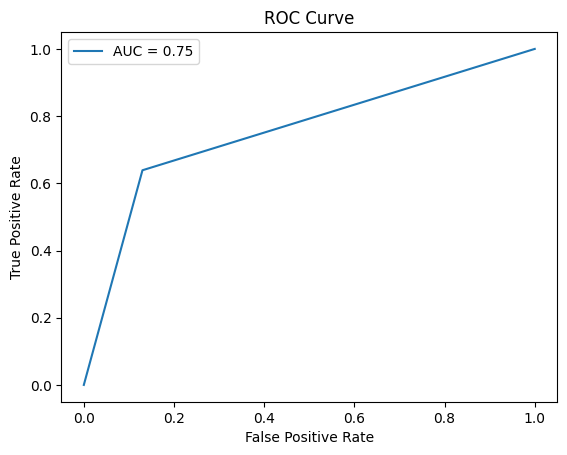

In [26]:
y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = " + str(round(roc_auc, 2)))
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [27]:
scores = cross_val_score(model, X, y, cv=5)

print("\nCross Validation Mean Accuracy:", scores.mean())
print("Standard Deviation:", scores.std())


Cross Validation Mean Accuracy: 0.8067438328802549
Standard Deviation: 0.004723467338224951


Conclusion: The Adult Census dataset was successfully analyzed using a Decision Tree model. After cleaning and encoding the data,the model achieved good accuracy with balanced precision and recall. ROC and AUC showed moderate performance, while cross-validation confirmed the model’s reliability. Overall, the model can reasonably predict income levels but can be further improved for better results.